In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import time

In [2]:
# Define stock universe
tickers = ["AAPL", "MSFT", "AMZN", "TSLA", "NVDA", "JPM"]

# Define date range
start_date = "2015-01-01"
end_date = "2025-01-01"

In [3]:
all_data = {}

for ticker in tickers:
    print(f"Downloading data for {ticker}...")
    try:
        data = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False,
            threads=False
        )[["Close"]]

        data.columns = [ticker]
        all_data[ticker] = data

        time.sleep(2)  # pause to reduce chance of rate limiting

    except Exception as e:
        print(f"Failed for {ticker}: {e}")

# Combine all stocks into one DataFrame
daily_prices = pd.concat(all_data.values(), axis=1)

# Preview data
daily_prices.head()

,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-01-02,24.214901,39.767693,15.4260,14.620667,0.482985,46.274323
2015-01-05,23.532722,39.401985,15.1095,14.006000,0.474828,44.837738
2015-01-06,23.534939,38.823689,14.7645,14.085333,0.460432,43.675137
2015-01-07,23.864943,39.316936,14.9210,14.063333,0.459232,43.741776
2015-01-08,24.781895,40.473576,15.0230,14.041333,0.476507,44.719242


In [4]:
# Basic checks
print("Shape of dataset:", daily_prices.shape)
print("\nMissing values by stock:")
print(daily_prices.isnull().sum())

Shape of dataset: (2516, 6)

Missing values by stock:
AAPL    0
MSFT    0
AMZN    0
TSLA    0
NVDA    0
JPM     0
dtype: int64


In [5]:
# Convert daily prices to month-end prices
monthly_prices = daily_prices.resample("M").last()

# Display first 5 rows
monthly_prices.head()

/tmp/ipykernel_2158/1276049869.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = daily_prices.resample("M").last()


,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-01-31,25.949114,34.358738,17.726500,13.573333,0.460671,40.268787
2015-02-28,28.564182,37.558231,19.007999,13.556000,0.531331,45.378307
2015-03-31,27.668072,34.825943,18.605000,12.584667,0.504114,44.859951
2015-04-30,27.828178,41.660946,21.089001,15.070000,0.534702,47.155865
2015-05-31,29.089870,40.397194,21.461500,16.719999,0.535483,49.034355


In [6]:
# Remove rows where all values are missing
monthly_prices = monthly_prices.dropna(how="all")

# Forward fill any small missing values
monthly_prices = monthly_prices.ffill()

# Check again
print("Missing values after cleaning:")
print(monthly_prices.isnull().sum())

Missing values after cleaning:
AAPL    0
MSFT    0
AMZN    0
TSLA    0
NVDA    0
JPM     0
dtype: int64


In [8]:
import os

os.makedirs("data/processed", exist_ok=True)

In [9]:
# Save processed monthly price data
monthly_prices.to_csv("data/processed/monthly_prices.csv")

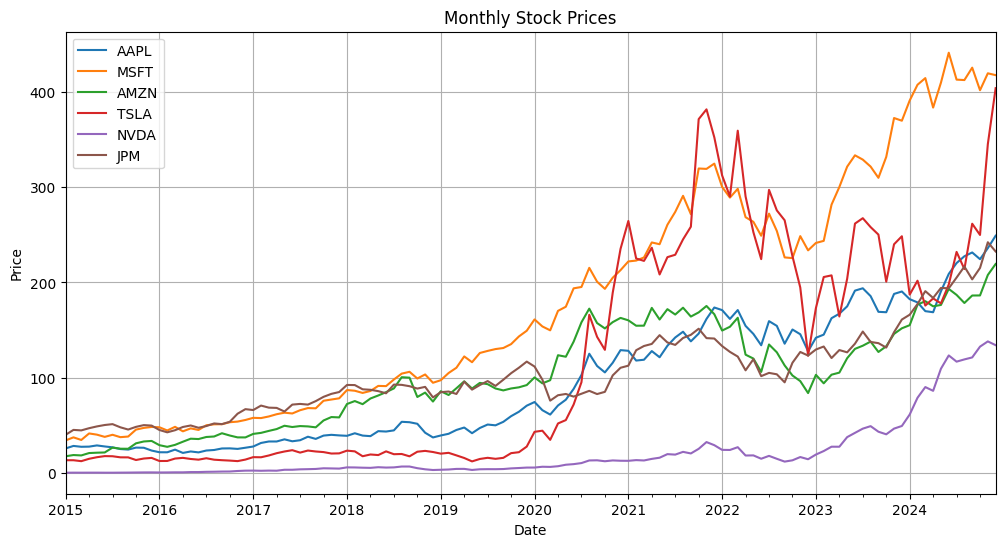

In [10]:
# Plot monthly prices
monthly_prices.plot(figsize=(12, 6))
plt.title("Monthly Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()